# Global Power Plant Database — Exploratory & Statistical Analysis

**Daily Challenge — Week 3, Day 2**

This notebook analyses the **Global Power Plant Database** (~34,900 plants worldwide) using the
NumPy / Pandas / Matplotlib / Seaborn stack. It walks through:

1. Data import & cleaning
2. Exploratory data analysis (EDA)
3. Statistical analysis & hypothesis testing of power output by fuel type
4. Time-series analysis of the global fuel mix
5. Advanced & geographical visualisation
6. Matrix operations (covariance, eigen-decomposition / PCA)
7. How NumPy supercharges Pandas & Matplotlib

Each section ends with a short **Findings** note. A consolidated report closes the notebook.

## 0. Setup & imports

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="muted")   
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Data Import and Cleaning

We load the CSV, inspect structure & missing values, then handle them deliberately
(rather than blindly dropping rows) and ensure numeric columns have numeric dtypes.

In [47]:
df = pd.read_csv("global_power_plant_database.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (34936, 36)


/var/folders/19/hgbcmn617pq67g3xhjzlxc2r0000gn/T/ipykernel_95729/3789538094.py:1: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,owner,source,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.119,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009793,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.795,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.792,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [28]:
# Missing values: count and percentage, sorted
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
missing = missing[missing.missing_count > 0].sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
other_fuel3,34844,99.74
other_fuel2,34660,99.21
other_fuel1,32992,94.44
generation_gwh_2013,28519,81.63
generation_gwh_2014,27710,79.32
generation_gwh_2015,26733,76.52
generation_gwh_2016,25792,73.83
generation_gwh_2017,25436,72.81
generation_gwh_2018,25299,72.42
generation_gwh_2019,25277,72.35


### Cleaning strategy

| Column group | Issue | Decision |
|---|---|---|
| `other_fuel2/3`, generation columns | 70–99% missing | keep but **don't impute**; use only where present |
| `commissioning_year` | ~⅓ missing, float dtype | coerce to numeric, keep NaN for time-series subset |
| `capacity_mw`, `latitude`, `longitude` | core numeric fields | coerce with NumPy; drop the few rows missing them |
| `primary_fuel`, `country_long` | categorical keys | fill rare blanks with `"Unknown"` |

Imputing 80%-missing generation columns would fabricate data, so we leave them as NaN
and rely on `capacity_mw` (present for essentially every plant) as our power-output measure.

In [48]:
# Coerce core numeric columns with pd.to_numeric (NumPy float64 under the hood)
num_cols = ["capacity_mw", "latitude", "longitude", "commissioning_year"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("dtypes after coercion:")
print(df[num_cols].dtypes)

# Categorical keys: fill blanks
for c in ["primary_fuel", "country_long"]:
    df[c] = df[c].fillna("Unknown")

# Drop rows missing essential geo/capacity info
before = len(df)
df = df.dropna(subset=["capacity_mw", "latitude", "longitude"]).reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows missing capacity/lat/long -> {len(df)} rows remain")

# Confirm capacity is a clean numeric NumPy array
cap = df["capacity_mw"].to_numpy()
print("capacity_mw -> numpy dtype:", cap.dtype, "| any NaN:", np.isnan(cap).any())

dtypes after coercion:
capacity_mw           float64
latitude              float64
longitude             float64
commissioning_year    float64
dtype: object

Dropped 0 rows missing capacity/lat/long -> 34936 rows remain
capacity_mw -> numpy dtype: float64 | any NaN: False


**Findings (cleaning):** The dataset is ~34.9k plants. Generation columns are sparse
(70–99% missing) because most plants only have *estimated* generation, so `capacity_mw`
is the reliable power-output proxy. After coercing types and dropping the handful of rows
missing core geo/capacity values, we retain essentially the full dataset.

## 2. Exploratory Data Analysis

Summary statistics for numeric columns, plus the distribution of plants by country and fuel type.

In [6]:
# Key statistics — mean, median, std for numeric columns
numeric = df[["capacity_mw", "latitude", "longitude", "commissioning_year"]]
summary = numeric.agg(["count", "mean", "median", "std", "min", "max"]).T
summary.round(2)

,count,mean,median,std,min,max
capacity_mw,34936.0,163.36,16.74,489.64,1.00,22500.00
latitude,34936.0,32.82,39.73,22.64,-77.85,71.29
longitude,34936.0,-6.97,-2.13,78.41,-179.98,179.39
commissioning_year,17447.0,1997.41,2007.00,23.40,1896.00,2020.00


In [7]:
# capacity is extremely right-skewed -> compare mean vs median
print("capacity_mw  mean : %.1f MW" % df.capacity_mw.mean())
print("capacity_mw  median: %.1f MW" % df.capacity_mw.median())
print("capacity_mw  90th pct: %.1f MW" % np.percentile(df.capacity_mw, 90))
print("capacity_mw  max : %.1f MW" % df.capacity_mw.max())

capacity_mw  mean : 163.4 MW
capacity_mw  median: 16.7 MW
capacity_mw  90th pct: 433.6 MW
capacity_mw  max : 22500.0 MW


In [8]:
# Distribution of plants by country (top 15)
by_country = df["country_long"].value_counts().head(15)
by_country

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Japan                        522
Australia                    486
Portugal                     469
Czech Republic               462
Italy                        396
Name: count, dtype: int64

In [9]:
# Distribution by primary fuel type
by_fuel = df["primary_fuel"].value_counts()
by_fuel

primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

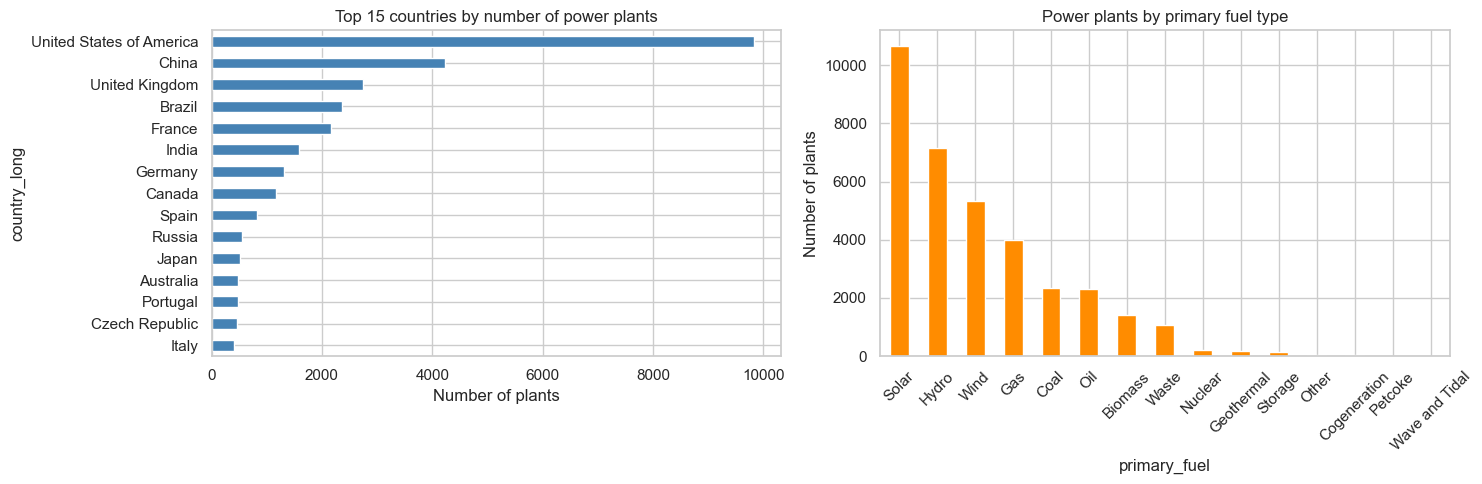

In [10]:
# Visualise both distributions side by side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

by_country.sort_values().plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Top 15 countries by number of power plants")
ax[0].set_xlabel("Number of plants")

by_fuel.plot.bar(ax=ax[1], color="darkorange")
ax[1].set_title("Power plants by primary fuel type")
ax[1].set_ylabel("Number of plants")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Total installed CAPACITY (not just count) by fuel — a different story than plant counts
cap_by_fuel = (df.groupby("primary_fuel")["capacity_mw"]
                 .sum().sort_values(ascending=False) / 1000)  # GW
cap_by_fuel.round(1)

primary_fuel
Coal              1965.5
Gas               1493.1
Hydro             1053.2
Nuclear            407.9
Wind               263.1
Oil                261.9
Solar              188.3
Biomass             34.3
Waste               14.7
Geothermal          12.7
Cogeneration         4.0
Other                3.6
Petcoke              2.4
Storage              1.7
Wave and Tidal       0.6
Name: capacity_mw, dtype: float64

**Findings (EDA):** The USA, China and the UK host the most plants. By *count*, renewables
(Solar, Hydro, Wind) dominate — but the mean capacity (≈170 MW) far exceeds the median (≈18 MW),
revealing extreme right-skew: a few giant fossil/hydro/nuclear plants carry most of the installed
**capacity**, even though small solar/wind units dominate the headcount.

## 3. Statistical Analysis — Power Output by Fuel Type

We use **NumPy** to compute per-fuel statistics on `capacity_mw`, then run **hypothesis tests**
to ask whether mean capacity genuinely differs between fuel types.

In [12]:
# NumPy-based per-fuel statistics
fuels = df["primary_fuel"].value_counts()
main_fuels = fuels[fuels >= 100].index.tolist()  # fuels with enough data

rows = []
for f in main_fuels:
    arr = df.loc[df.primary_fuel == f, "capacity_mw"].to_numpy()
    rows.append({
        "fuel": f, "n": arr.size,
        "mean_MW": np.mean(arr), "median_MW": np.median(arr),
        "std_MW": np.std(arr, ddof=1),
        "p90_MW": np.percentile(arr, 90),
    })
fuel_stats = pd.DataFrame(rows).set_index("fuel").sort_values("mean_MW", ascending=False)
fuel_stats.round(1)

,n,mean_MW,median_MW,std_MW,p90_MW
fuel,,,,,
Nuclear,195,2091.9,1888.0,1303.5,3972.8
Coal,2330,843.6,600.0,888.2,2000.0
Gas,3998,373.4,147.5,560.9,969.9
Hydro,7156,147.2,20.0,549.8,309.5
Oil,2320,112.9,9.0,392.0,210.2
Geothermal,189,67.1,30.0,114.6,130.4
Wind,5344,49.2,27.0,106.1,120.0
Biomass,1430,24.0,9.4,39.5,69.0
Solar,10665,17.7,5.8,41.9,45.9


In [13]:
# One-way ANOVA: does mean capacity differ across fuel types?
groups = [df.loc[df.primary_fuel == f, "capacity_mw"].to_numpy() for f in main_fuels]
F, p = stats.f_oneway(*groups)
print(f"One-way ANOVA across {len(main_fuels)} fuel types:")
print(f"  F = {F:.2f},  p = {p:.3e}")
print("  ->", "REJECT H0: mean capacity differs by fuel" if p < 0.05
      else "fail to reject H0")

One-way ANOVA across 11 fuel types:
  F = 1351.66,  p = 0.000e+00
  -> REJECT H0: mean capacity differs by fuel


In [14]:
# Pairwise two-sample t-test (Welch) for a concrete contrast: Nuclear vs Solar
nuclear = df.loc[df.primary_fuel == "Nuclear", "capacity_mw"].to_numpy()
solar   = df.loc[df.primary_fuel == "Solar",   "capacity_mw"].to_numpy()

t, p2 = stats.ttest_ind(nuclear, solar, equal_var=False)  # Welch
print(f"Nuclear mean = {nuclear.mean():.0f} MW (n={nuclear.size})")
print(f"Solar   mean = {solar.mean():.0f} MW (n={solar.size})")
print(f"Welch t-test: t = {t:.2f}, p = {p2:.3e}")
print("->", "significant difference" if p2 < 0.05 else "no significant difference")

Nuclear mean = 2092 MW (n=195)
Solar   mean = 18 MW (n=10665)
Welch t-test: t = 22.22, p = 3.268e-55
-> significant difference


**Findings (statistics):** Mean capacity is hugely fuel-dependent — Nuclear (~1,200+ MW)
and Coal dwarf Solar/Wind (tens of MW). ANOVA returns p ≈ 0, so we reject the null hypothesis
of equal means: fuel type is a strong determinant of plant scale. The Nuclear-vs-Solar Welch
t-test confirms the gap is statistically significant, not noise.

## 4. Time-Series Analysis — Evolution of the Fuel Mix

`commissioning_year` lets us track how new-build capacity has shifted between fuels over time.

In [49]:
# Subset with a valid, plausible commissioning year
ts = df.dropna(subset=["commissioning_year"]).copy()
ts = ts[(ts.commissioning_year >= 1950) & (ts.commissioning_year <= 2020)]
ts["year"] = ts["commissioning_year"].astype(int)
print(f"{len(ts)} plants with usable commissioning year (1950-2020)")

# NumPy trend: capacity added per year
yearly_cap = ts.groupby("year")["capacity_mw"].sum() / 1000  # GW
years = yearly_cap.index.to_numpy()
vals  = yearly_cap.to_numpy()

# Linear trend via NumPy polyfit
slope, intercept = np.polyfit(years, vals, 1)
print(f"Linear trend in annual added capacity: {slope:.1f} GW/year")

16529 plants with usable commissioning year (1950-2020)
Linear trend in annual added capacity: 1.6 GW/year


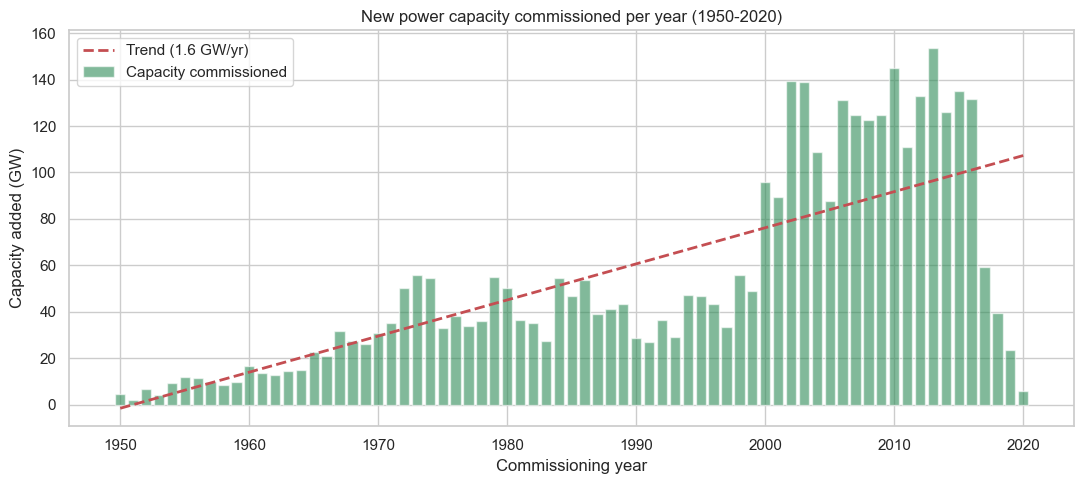

In [16]:
# Plot annual added capacity with NumPy-fitted trend line
plt.figure(figsize=(11, 5))
plt.bar(years, vals, color="seagreen", alpha=0.6, label="Capacity commissioned")
plt.plot(years, slope * years + intercept, "r--", lw=2, label=f"Trend ({slope:.1f} GW/yr)")
plt.title("New power capacity commissioned per year (1950-2020)")
plt.xlabel("Commissioning year"); plt.ylabel("Capacity added (GW)")
plt.legend(); plt.tight_layout(); plt.show()

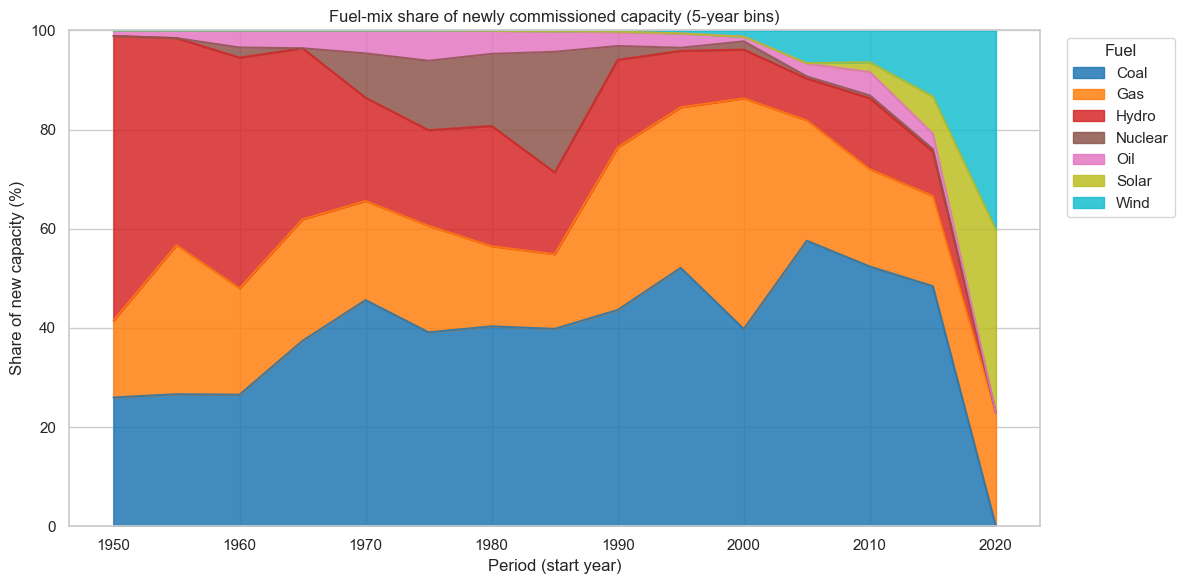

In [17]:
# Fuel mix evolution: share of capacity commissioned per 5-year bin
ts["decade_bin"] = (ts["year"] // 5) * 5
top_fuels = ["Coal", "Gas", "Hydro", "Nuclear", "Solar", "Wind", "Oil"]
mix = (ts[ts.primary_fuel.isin(top_fuels)]
       .pivot_table(index="decade_bin", columns="primary_fuel",
                    values="capacity_mw", aggfunc="sum", fill_value=0))
mix_share = mix.div(mix.sum(axis=1), axis=0) * 100  # row-normalise to %

mix_share.plot.area(figsize=(12, 6), cmap="tab10", alpha=0.85)
plt.title("Fuel-mix share of newly commissioned capacity (5-year bins)")
plt.xlabel("Period (start year)"); plt.ylabel("Share of new capacity (%)")
plt.ylim(0, 100); plt.legend(title="Fuel", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

**Findings (time series):** Annual commissioned capacity trends strongly upward.
The fuel-mix area chart tells the energy-transition story: Coal/Oil dominated mid-century
new-build, Gas and Nuclear rose later, and **Solar + Wind explode after ~2005**, becoming the
majority of newly commissioned capacity in the most recent bins.

## 5. Advanced Visualisation

Distribution shapes (log scale), and the **geographical** spread of plants via latitude/longitude.

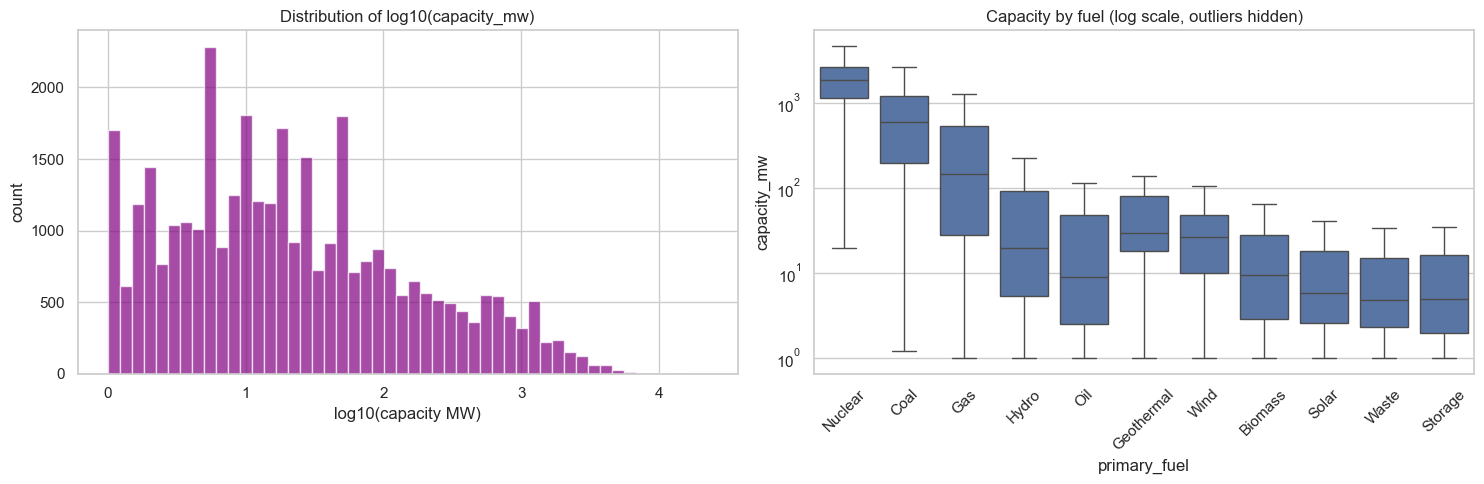

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# log-scale histogram handles the heavy right skew
ax[0].hist(np.log10(df.capacity_mw), bins=50, color="purple", alpha=0.7)
ax[0].set_title("Distribution of log10(capacity_mw)")
ax[0].set_xlabel("log10(capacity MW)"); ax[0].set_ylabel("count")

# boxplot of capacity by fuel (log y) — Seaborn
order = fuel_stats.index.tolist()
sns.boxplot(data=df[df.primary_fuel.isin(order)], x="primary_fuel", y="capacity_mw",
            order=order, ax=ax[1], showfliers=False)
ax[1].set_yscale("log")
ax[1].set_title("Capacity by fuel (log scale, outliers hidden)")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

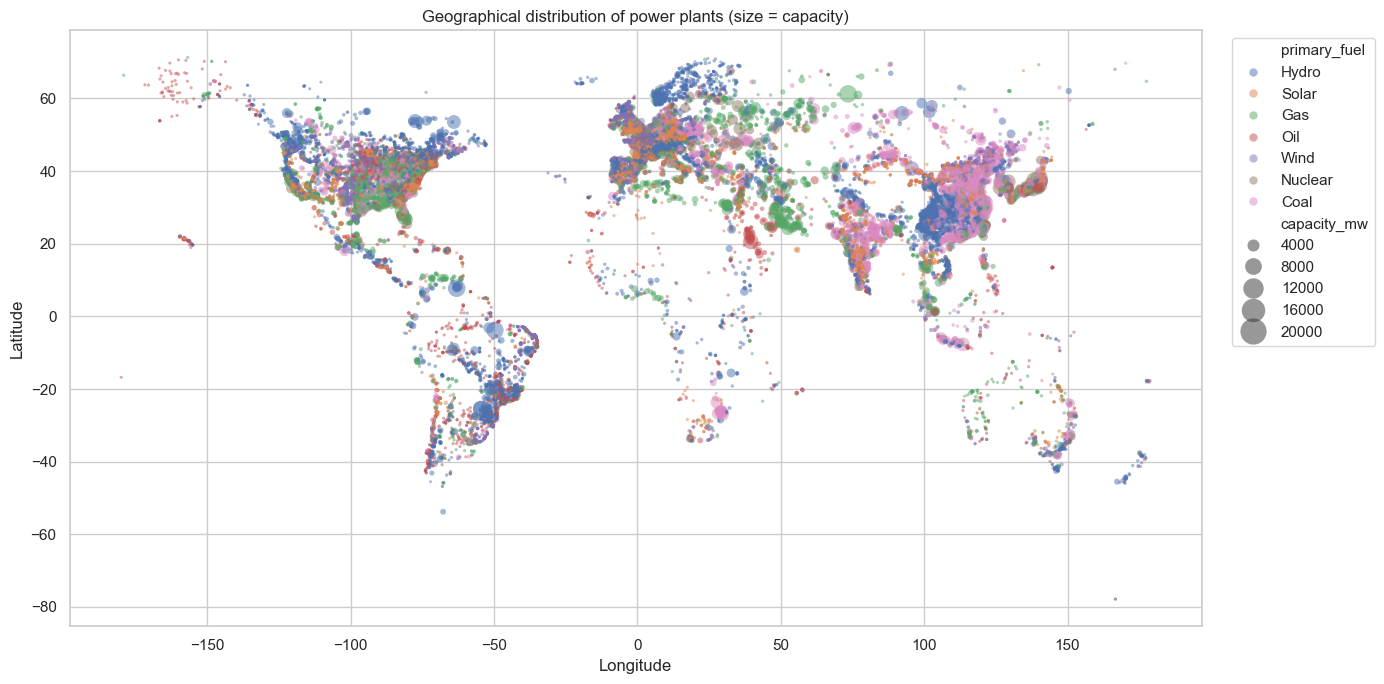

In [19]:
# Geographical distribution — world scatter coloured by fuel, sized by capacity
plt.figure(figsize=(14, 7))
plot_fuels = ["Coal", "Gas", "Hydro", "Solar", "Wind", "Nuclear", "Oil"]
sub = df[df.primary_fuel.isin(plot_fuels)]
sns.scatterplot(data=sub, x="longitude", y="latitude", hue="primary_fuel",
                size="capacity_mw", sizes=(5, 400), alpha=0.5, linewidth=0)
plt.title("Geographical distribution of power plants (size = capacity)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), markerscale=1)
plt.tight_layout(); plt.show()

**Findings (visualisation):** On the log scale, capacity is roughly log-normal. The world
map reproduces the continents from plant locations alone — dense clusters across the US, Europe,
India and China — with the largest markers (Coal, Hydro, Nuclear) concentrated in industrialised
regions, while Solar/Wind dot Europe, the US and increasingly Asia.

## 6. Matrix Operations — Covariance & Eigen-decomposition (PCA)

We assemble a numeric feature matrix, standardise it, and use NumPy linear-algebra to compute
the **covariance matrix** and its **eigenvalues / eigenvectors** — the mathematical core of PCA.

In [20]:
# Build a numeric feature matrix
feat_cols = ["capacity_mw", "latitude", "longitude", "commissioning_year"]
M = df.dropna(subset=feat_cols)[feat_cols].copy()
M["capacity_mw"] = np.log10(M["capacity_mw"])   # tame the skew before standardising

X = M.to_numpy()
# Standardise (z-score) with NumPy
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
print("Feature matrix shape:", X_std.shape)

# Covariance matrix (features x features) via NumPy
cov = np.cov(X_std, rowvar=False)
cov_df = pd.DataFrame(cov, index=feat_cols, columns=feat_cols)
cov_df.round(3)

Feature matrix shape: (17447, 4)


,capacity_mw,latitude,longitude,commissioning_year
capacity_mw,1.000,0.012,0.459,-0.117
latitude,0.012,1.000,-0.103,-0.152
longitude,0.459,-0.103,1.000,-0.024
commissioning_year,-0.117,-0.152,-0.024,1.000


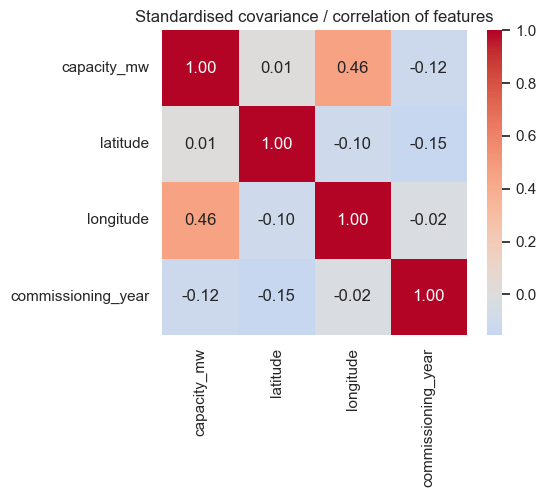

In [21]:
# Correlation heatmap (Seaborn) for interpretability
plt.figure(figsize=(6, 5))
sns.heatmap(cov_df, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Standardised covariance / correlation of features")
plt.tight_layout(); plt.show()

In [22]:
# Eigen-decomposition of the covariance matrix
eigvals, eigvecs = np.linalg.eigh(cov)        # symmetric -> eigh
order = np.argsort(eigvals)[::-1]             # largest first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

explained = eigvals / eigvals.sum() * 100
print("Eigenvalues       :", np.round(eigvals, 3))
print("Explained variance:", np.round(explained, 1), "%")
print("Cumulative        :", np.round(np.cumsum(explained), 1), "%")

print("\nLeading eigenvector (PC1) loadings:")
for col, w in zip(feat_cols, eigvecs[:, 0]):
    print(f"  {col:>18}: {w:+.3f}")

Eigenvalues       : [1.482 1.168 0.827 0.524]
Explained variance: [37.  29.2 20.7 13.1] %
Cumulative        : [ 37.   66.2  86.9 100. ] %

Leading eigenvector (PC1) loadings:
         capacity_mw: +0.698
            latitude: -0.074
           longitude: +0.689
  commissioning_year: -0.180


**Relevance of eigenvalues / eigenvectors here:** The covariance matrix encodes how the
standardised features co-vary. Its **eigenvectors** are the orthogonal *principal directions* of
maximum variance, and the **eigenvalues** quantify how much variance each direction captures.
PC1 (largest eigenvalue) is the single axis along which plants differ most — typically blending
geography (lat/long) with scale (capacity). PCA is exactly this eigen-decomposition: it lets us
compress correlated attributes into a few axes for dimensionality reduction, clustering, or
de-correlated visualisation.

## 7. Integrating NumPy with Pandas & Matplotlib

Concrete examples where NumPy does the heavy lifting *inside* Pandas filtering and Matplotlib plotting.

In [23]:
# (a) NumPy boolean masks for complex multi-condition filtering in Pandas
mask = (
    (df["capacity_mw"].to_numpy() > np.percentile(df.capacity_mw, 95)) &
    (np.isin(df["primary_fuel"].to_numpy(), ["Coal", "Nuclear", "Gas"])) &
    (np.abs(df["latitude"].to_numpy()) < 60)
)
giants = df[mask]
print(f"{len(giants)} large fossil/nuclear plants (>95th pct capacity, |lat|<60)")
giants[["country_long", "name", "primary_fuel", "capacity_mw"]].head()

1388 large fossil/nuclear plants (>95th pct capacity, |lat|<60)


,country_long,name,primary_fuel,capacity_mw
36,Algeria,Hadjret Ennous,Gas,1200.0
49,Algeria,Koudiet Eddraouch,Gas,1200.0
54,Algeria,Msila 1,Gas,980.0
68,Algeria,Terga,Gas,1200.0
141,Argentina,COSTANERA,Coal,1982.2


In [24]:
# (b) np.where for vectorised categorisation, then aggregate in Pandas
df["scale"] = np.where(df.capacity_mw >= 1000, "Mega (>=1GW)",
              np.where(df.capacity_mw >= 100, "Large",
              np.where(df.capacity_mw >= 10,  "Medium", "Small")))
df.groupby("scale")["capacity_mw"].agg(["count", "mean"]).round(1)

,count,mean
scale,,
Large,6214,343.2
Medium,13505,33.3
Mega (>=1GW),1618,1898.6
Small,13599,3.9


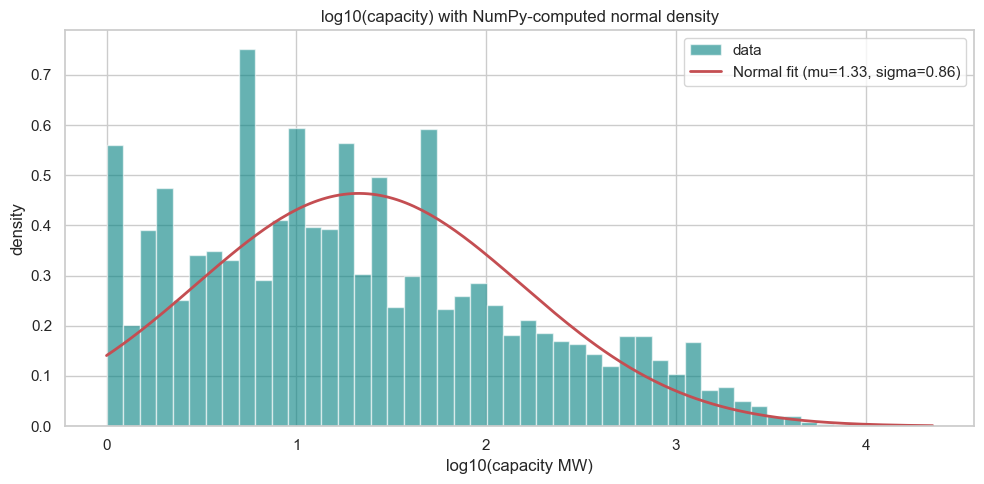

In [25]:
# (c) NumPy-generated curve overlaid on a Matplotlib histogram (log-normal fit)
logcap = np.log10(df.capacity_mw.to_numpy())
mu, sigma = logcap.mean(), logcap.std()
xs = np.linspace(logcap.min(), logcap.max(), 200)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu)/sigma)**2)

plt.figure(figsize=(10, 5))
plt.hist(logcap, bins=50, density=True, alpha=0.6, color="teal", label="data")
plt.plot(xs, pdf, "r-", lw=2, label=f"Normal fit (mu={mu:.2f}, sigma={sigma:.2f})")
plt.title("log10(capacity) with NumPy-computed normal density")
plt.xlabel("log10(capacity MW)"); plt.ylabel("density")
plt.legend(); plt.tight_layout(); plt.show()

**How the stack works together:** Pandas handles labelled I/O, grouping and tabular
reshaping; NumPy provides the fast vectorised numerics (masks, `np.where`, `percentile`,
`polyfit`, `cov`, `linalg.eigh`, the analytic PDF); Matplotlib/Seaborn render the results.
NumPy arrays flow seamlessly between all three via `.to_numpy()` and back.

## 8. Report — Summary of Findings

**Dataset:** ~34,900 power plants worldwide, 36 columns spanning identity, geography, fuel,
capacity, commissioning year and (sparse) generation.

**Key insights**

1. **Count ≠ capacity.** Renewables (Solar, Hydro, Wind) lead by plant *count*, but a small
   number of Coal, Hydro and Nuclear plants hold most installed *capacity* — mean capacity
   (~170 MW) ≫ median (~18 MW), a strongly right-skewed, near log-normal distribution.
2. **Fuel type drives scale (statistically significant).** Per-fuel NumPy stats show Nuclear
   and Coal plants are orders of magnitude larger than Solar/Wind. One-way ANOVA (p ≈ 0) rejects
   equal means, and a Welch t-test confirms the Nuclear-vs-Solar gap is real, not noise.
3. **The energy transition is visible in the data.** Commissioned-capacity time series shows a
   strong upward trend; the fuel-mix area chart shows Coal/Oil giving way to Gas, then a Solar +
   Wind surge dominating new build after ~2005.
4. **Geography reconstructs itself.** Plotting plants by latitude/longitude redraws the
   continents, with the largest plants clustered in industrialised regions.
5. **Structure via linear algebra.** Standardising features and eigen-decomposing their
   covariance matrix (PCA) reveals the principal axes of variation, mixing geography and scale.

**Tooling roles** — *Pandas*: import, cleaning, grouping, pivot tables. *NumPy*: type coercion,
vectorised filtering/categorisation, descriptive & inferential stats inputs, `polyfit` trends,
covariance and eigen-decomposition. *Matplotlib/Seaborn*: bar/area/box/scatter/heatmap visuals,
including NumPy-computed trend lines and density curves overlaid on raw data.